# Pricing Demand Forecasting and GPI Scenario Analysis

This portfolio proof of concept uses synthetic daily pricing and promotional data to estimate case demand and compare pricing scenarios during general price increase (GPI) planning.

The analysis focuses on a practical business question: how might changes in price and discount affect case demand, revenue, and profit after accounting for calendar effects and recent demand?

Important: The results are simulated estimates based on synthetic data. They are not validated production forecasts.

## 1. Setup and Data Loading

The notebook loads the project dataset with a repository-relative path so it can run from either the project root or the notebooks folder.

In [5]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "pricing_portfolio_data.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "pricing_model_package.pkl"

df = pd.read_csv(DATA_PATH)

## 2. Data Understanding and Quality Checks

The target is cases_sold. Price and discount are controllable pricing inputs, while holiday status and weekday provide business context that the firm cannot directly control.

In [6]:
display(df.head())
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print("\nColumn information:")
df.info()

,date,price,discount,is_holiday,cases_sold,day_of_week
0,2025-03-02,20.12,0.30,0,2168,Sunday
1,2025-03-03,18.59,0.00,0,1088,Monday
2,2025-03-04,17.91,0.08,0,1426,Tuesday
3,2025-03-05,17.64,0.10,0,1419,Wednesday
4,2025-03-06,23.33,0.00,0,494,Thursday


Rows: 517
Columns: 6
Duplicate rows: 0

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         517 non-null    object 
 1   price        517 non-null    float64
 2   discount     517 non-null    float64
 3   is_holiday   517 non-null    int64  
 4   cases_sold   517 non-null    int64  
 5   day_of_week  517 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 24.4+ KB


In [7]:
quality_summary = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isnull().sum(),
    "unique_values": df.nunique(),
})
quality_summary

,data_type,missing_values,unique_values
date,object,0,517
price,float64,0,365
discount,float64,0,9
is_holiday,int64,0,2
cases_sold,int64,0,432
day_of_week,object,0,7


## 3. Date Preparation

Dates are converted to a date type and sorted from earliest to latest. Maintaining this order is necessary because the model is evaluated by training on earlier observations and testing on later observations.

In [8]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Date range: 2025-03-02 to 2026-07-31


## 4. Exploratory Analysis

The following views examine demand over time and the simple relationships among price, discount, and cases sold.

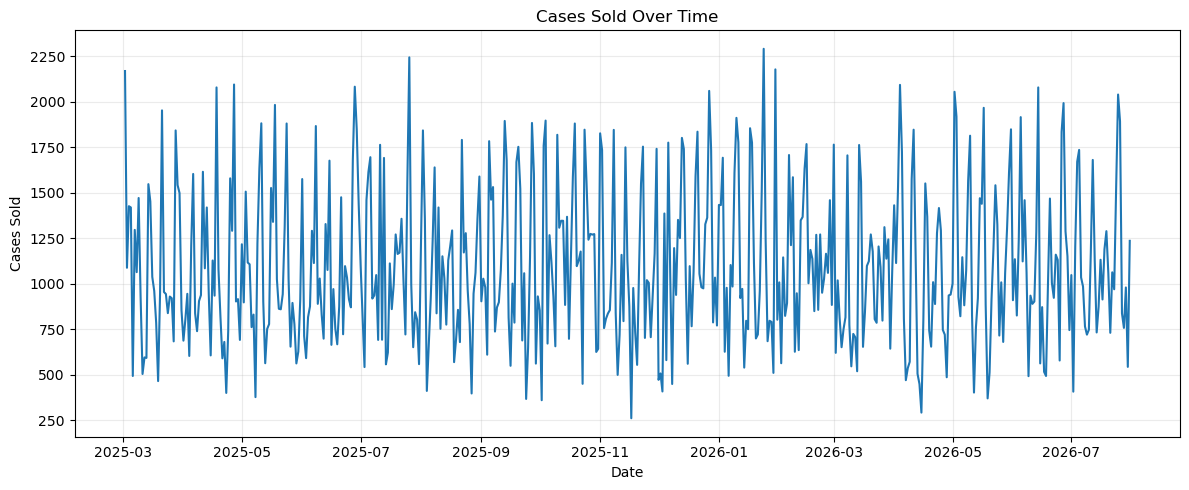

In [9]:
daily_sales = df.groupby("date")["cases_sold"].sum()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales.values, color="tab:blue")
plt.title("Cases Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Cases Sold")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [10]:
correlation = df[["price", "discount", "cases_sold"]].corr()
correlation.round(3)

,price,discount,cases_sold
price,1.000,0.054,-0.311
discount,0.054,1.000,0.854
cases_sold,-0.311,0.854,1.000


## 5. Feature Engineering

Two recent-demand features are created without using the current row's target:

- cases_lag_7: cases sold seven observations earlier
- cases_roll_7: average cases sold across the previous seven observations

Weekday categories are converted into indicator columns. Friday is the reference weekday because the first category is dropped.

In [11]:
df["cases_lag_7"] = df["cases_sold"].shift(7)
df["cases_roll_7"] = df["cases_sold"].shift(1).rolling(7).mean()
df = df.dropna().reset_index(drop=True)

df = pd.get_dummies(
    df,
    columns=["day_of_week"],
    drop_first=True,
    dtype=int,
)

In [12]:
feature_columns = [
    "price",
    "discount",
    "is_holiday",
    "cases_lag_7",
    "cases_roll_7",
    "day_of_week_Monday",
    "day_of_week_Tuesday",
    "day_of_week_Wednesday",
    "day_of_week_Thursday",
    "day_of_week_Saturday",
    "day_of_week_Sunday",
]

X = df[feature_columns]
y = df["cases_sold"]

display(X.head())
print(f"Modeling observations after feature engineering: {len(X):,}")

,price,discount,is_holiday,cases_lag_7,cases_roll_7,day_of_week_Monday,day_of_week_Tuesday,day_of_week_Wednesday,day_of_week_Thursday,day_of_week_Saturday,day_of_week_Sunday
0,19.55,0.10,0,2168.0,1279.285714,0,0,0,0,0,1
1,20.69,0.05,0,1088.0,1179.714286,1,0,0,0,0,0
2,21.65,0.00,0,1426.0,1157.285714,0,1,0,0,0,0
3,21.75,0.00,0,1419.0,1025.714286,0,0,1,0,0,0
4,22.29,0.00,0,494.0,908.142857,0,0,0,1,0,0


Modeling observations after feature engineering: 510


## 6. Chronological Train/Test Split

The first 80% of observations are used for training and the latest 20% are held out for testing. This represents the real forecasting direction: learning from the past and evaluating on later data.

In [13]:
split_point = int(len(df) * 0.80)

X_train = X.iloc[:split_point].to_numpy()
y_train = y.iloc[:split_point].to_numpy()
X_test = X.iloc[split_point:].to_numpy()
y_test = y.iloc[split_point:].to_numpy()

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")
print(f"Training period: {df.loc[:split_point - 1, 'date'].min().date()} to {df.loc[:split_point - 1, 'date'].max().date()}")
print(f"Testing period: {df.loc[split_point:, 'date'].min().date()} to {df.loc[split_point:, 'date'].max().date()}")

Training observations: 408
Testing observations: 102
Training period: 2025-03-09 to 2026-04-20
Testing period: 2026-04-21 to 2026-07-31


## 7. Linear Regression Model

Linear regression provides an interpretable baseline for estimating case demand. Coefficients show the direction and estimated size of each feature's relationship with predicted demand while the other model inputs remain fixed.

In [14]:
model = LinearRegression()
model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

coefficient_table = pd.DataFrame({
    "feature": feature_columns,
    "coefficient": model.coef_,
}).sort_values("coefficient", ascending=False)

print(f"Model intercept: {model.intercept_:,.3f}")
coefficient_table

Model intercept: 2,336.872


,feature,coefficient
1,discount,3513.332885
2,is_holiday,412.853707
9,day_of_week_Saturday,281.236353
10,day_of_week_Sunday,231.129000
6,day_of_week_Tuesday,14.114678
4,cases_roll_7,0.018200
3,cases_lag_7,-0.006415
8,day_of_week_Thursday,-8.641712
7,day_of_week_Wednesday,-11.660075
5,day_of_week_Monday,-27.452484


## 8. Model Evaluation

R-squared measures the share of variation in cases sold explained by the model relative to predicting the average. RMSE summarizes prediction error in cases sold and gives greater weight to larger errors.

In [15]:
evaluation = pd.DataFrame({
    "dataset": ["Training", "Testing"],
    "r_squared": [
        r2_score(y_train, train_predictions),
        r2_score(y_test, test_predictions),
    ],
    "mse": [
        mean_squared_error(y_train, train_predictions),
        mean_squared_error(y_test, test_predictions),
    ],
    "rmse_cases": [
        root_mean_squared_error(y_train, train_predictions),
        root_mean_squared_error(y_test, test_predictions),
    ],
})

evaluation.round(3)

,dataset,r_squared,mse,rmse_cases
0,Training,0.929,12614.014,112.312
1,Testing,0.907,15971.634,126.379


### Cross-Validation Comparison

Standard five-fold cross-validation is retained as a general benchmark. However, it does not preserve the forecasting direction in every fold because some training folds may contain later observations.

TimeSeriesSplit is the primary validation method because each fold trains on earlier observations and evaluates on later observations.

In [16]:
standard_cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2",
)

time_series_split = TimeSeriesSplit(n_splits=5)
time_series_cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=time_series_split,
    scoring="r2",
)

cv_results = pd.DataFrame({
    "fold": range(1, 6),
    "standard_cv_r_squared": standard_cv_scores,
    "time_series_r_squared": time_series_cv_scores,
})

display(cv_results.round(3))
print(f"Standard CV average R-squared: {standard_cv_scores.mean():.3f}")
print(f"Time-series CV average R-squared: {time_series_cv_scores.mean():.3f}")

,fold,standard_cv_r_squared,time_series_r_squared
0,1,0.931,0.901
1,2,0.928,0.917
2,3,0.907,0.934
3,4,0.929,0.903
4,5,0.907,0.911


Standard CV average R-squared: 0.920
Time-series CV average R-squared: 0.913


## 9. Prediction Diagnostics

Residuals are calculated as actual cases sold minus predicted cases sold. The charts below help identify prediction bias, unusually large errors, and patterns not captured by the model.

In [17]:
prediction_results = pd.DataFrame({
    "date": df.loc[split_point:, "date"].to_numpy(),
    "actual_cases": y_test,
    "predicted_cases": test_predictions,
})
prediction_results["residual"] = (
    prediction_results["actual_cases"] - prediction_results["predicted_cases"]
)
prediction_results["absolute_error"] = prediction_results["residual"].abs()

prediction_results.sort_values("absolute_error", ascending=False).head(10)

,date,actual_cases,predicted_cases,residual,absolute_error
39,2026-05-30,1613,1953.091616,-340.091616,340.091616
88,2026-07-18,1189,1485.459591,-296.459591,296.459591
40,2026-05-31,1848,1568.640881,279.359119,279.359119
42,2026-06-02,1135,865.494096,269.505904,269.505904
64,2026-06-24,1131,865.772942,265.227058,265.227058
12,2026-05-03,1918,1655.710377,262.289623,262.289623
4,2026-04-25,1293,1543.589299,-250.589299,250.589299
22,2026-05-13,761,521.069841,239.930159,239.930159
68,2026-06-28,1288,1087.667360,200.332640,200.332640
37,2026-05-28,1060,865.269965,194.730035,194.730035


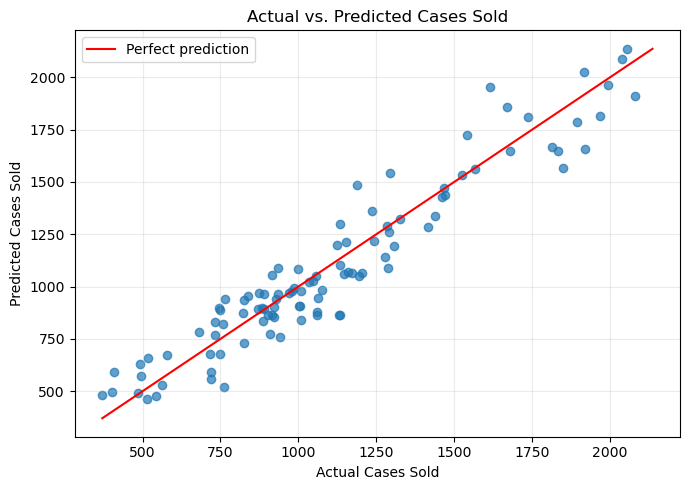

In [18]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, test_predictions, alpha=0.7)
comparison_min = min(y_test.min(), test_predictions.min())
comparison_max = max(y_test.max(), test_predictions.max())
plt.plot(
    [comparison_min, comparison_max],
    [comparison_min, comparison_max],
    color="red",
    label="Perfect prediction",
)
plt.xlabel("Actual Cases Sold")
plt.ylabel("Predicted Cases Sold")
plt.title("Actual vs. Predicted Cases Sold")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

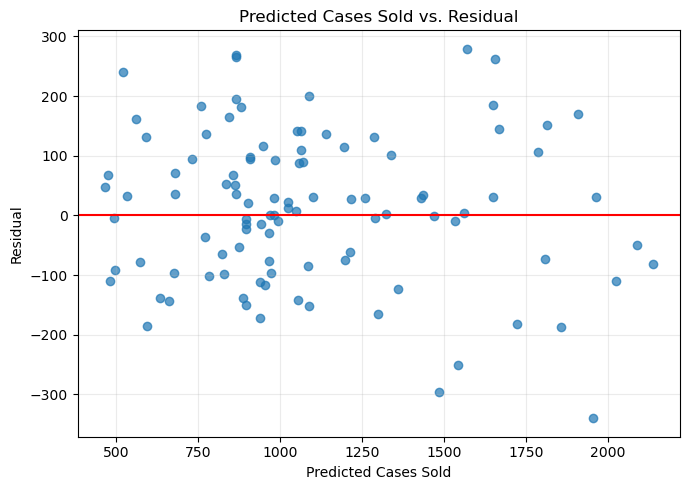

In [19]:
plt.figure(figsize=(7, 5))
plt.scatter(
    prediction_results["predicted_cases"],
    prediction_results["residual"],
    alpha=0.7,
)
plt.axhline(y=0, color="red")
plt.xlabel("Predicted Cases Sold")
plt.ylabel("Residual")
plt.title("Predicted Cases Sold vs. Residual")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 10. Statistical Coefficient Review

An ordinary least squares model provides standard errors and p-values for an exploratory review of the linear coefficients. This full-dataset analysis is used for interpretation, not as the held-out performance estimate.

In [27]:
X_ols = sm.add_constant(X).astype(float)
ols_model = sm.OLS(y, X_ols).fit()

ols_results = pd.DataFrame({
    "coefficient": ols_model.params,
    "standard_error": ols_model.bse,
    "p_value": ols_model.pvalues,
})
ols_results.round(4)

,coefficient,standard_error,p_value
const,2371.3908,72.2577,0.0000
price,-77.1998,2.5038,0.0000
discount,3468.1330,74.3997,0.0000
is_holiday,376.5560,52.7784,0.0000
cases_lag_7,0.0016,0.0180,0.9277
cases_roll_7,-0.0061,0.0467,0.8960
day_of_week_Monday,-31.8890,23.0993,0.1680
day_of_week_Tuesday,0.4307,23.1710,0.9852
day_of_week_Wednesday,-19.7443,23.1926,0.3950
day_of_week_Thursday,-15.0901,23.2111,0.5159


In [28]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             cases_sold   R-squared:                       0.926
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                     564.0
Date:                Sun, 16 Aug 2026   Prob (F-statistic):          6.62e-273
Time:                        21:52:04   Log-Likelihood:                -3142.1
No. Observations:                 510   AIC:                             6308.
Df Residuals:                     498   BIC:                             6359.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  2371.39

## 11. Exploratory Price Elasticity Model

This secondary log model is included for interpretation and is not deployed in the Streamlit application. The log-price coefficient approximates price elasticity while holding the included controls fixed. Discount uses log1p because the dataset contains zero-discount observations.

In [21]:
elasticity_df = df.copy()
elasticity_df["log_cases"] = np.log(elasticity_df["cases_sold"])
elasticity_df["log_price"] = np.log(elasticity_df["price"])
elasticity_df["log_discount"] = np.log1p(elasticity_df["discount"])

elasticity_features = [
    "log_price",
    "log_discount",
    "is_holiday",
    "day_of_week_Monday",
    "day_of_week_Tuesday",
    "day_of_week_Wednesday",
    "day_of_week_Thursday",
    "day_of_week_Saturday",
    "day_of_week_Sunday",
]

X_elasticity = sm.add_constant(
    elasticity_df[elasticity_features]
).astype(float)
y_elasticity = elasticity_df["log_cases"]

elasticity_model = sm.OLS(y_elasticity, X_elasticity).fit()
elasticity_results = pd.DataFrame({
    "coefficient": elasticity_model.params,
    "standard_error": elasticity_model.bse,
    "p_value": elasticity_model.pvalues,
})

elasticity_results.round(4)

,coefficient,standard_error,p_value
const,12.0293,0.2021,0.0000
log_price,-1.7747,0.0666,0.0000
log_discount,3.2915,0.1062,0.0000
is_holiday,0.3941,0.0671,0.0000
day_of_week_Monday,-0.0623,0.0274,0.0236
day_of_week_Tuesday,-0.0312,0.0277,0.2607
day_of_week_Wednesday,-0.0584,0.0279,0.0368
day_of_week_Thursday,-0.0505,0.0276,0.0674
day_of_week_Saturday,0.2161,0.0248,0.0000
day_of_week_Sunday,0.2063,0.0247,0.0000


## 12. GPI Pricing Scenario Analysis

The scenarios compare potential demand, revenue, and profit outcomes across different price, discount, and weekday combinations. All scenarios are treated as non-holidays. Recent demand is represented by the average cases sold across the final 14 observations.

A fixed cost of $17 per case is used for this portfolio simulation.

In [22]:
scenarios = pd.DataFrame([
    {"strategy": "Premium", "price": 17.50, "discount": 0.00, "is_holiday": 0, "day_of_week": "Friday"},
    {"strategy": "Slight Promo", "price": 17.00, "discount": 0.05, "is_holiday": 0, "day_of_week": "Saturday"},
    {"strategy": "Standard Promo", "price": 20.00, "discount": 0.10, "is_holiday": 0, "day_of_week": "Sunday"},
    {"strategy": "Weekend Push", "price": 21.00, "discount": 0.15, "is_holiday": 0, "day_of_week": "Saturday"},
    {"strategy": "Deep Promo", "price": 19.00, "discount": 0.20, "is_holiday": 0, "day_of_week": "Friday"},
    {"strategy": "Inventory", "price": 22.00, "discount": 0.25, "is_holiday": 0, "day_of_week": "Sunday"},
    {"strategy": "Liquidation", "price": 23.00, "discount": 0.30, "is_holiday": 0, "day_of_week": "Saturday"},
])

scenarios

,strategy,price,discount,is_holiday,day_of_week
0,Premium,17.5,0.00,0,Friday
1,Slight Promo,17.0,0.05,0,Saturday
2,Standard Promo,20.0,0.10,0,Sunday
3,Weekend Push,21.0,0.15,0,Saturday
4,Deep Promo,19.0,0.20,0,Friday
5,Inventory,22.0,0.25,0,Sunday
6,Liquidation,23.0,0.30,0,Saturday


In [23]:
scenario_features = pd.get_dummies(
    scenarios.drop(columns=["strategy"]),
    columns=["day_of_week"],
    dtype=int,
)
scenario_features = scenario_features.reindex(
    columns=feature_columns,
    fill_value=0,
)

recent_level = df["cases_sold"].tail(14).mean()
scenario_features["cases_lag_7"] = recent_level
scenario_features["cases_roll_7"] = recent_level

scenarios["predicted_cases_sold"] = model.predict(
    scenario_features.to_numpy()
)

In [24]:
cost_per_case = 17.00
scenarios["net_price"] = scenarios["price"] * (1 - scenarios["discount"])
scenarios["predicted_revenue"] = (
    scenarios["net_price"] * scenarios["predicted_cases_sold"]
)
scenarios["profit_per_case"] = scenarios["net_price"] - cost_per_case
scenarios["predicted_profit"] = (
    scenarios["profit_per_case"] * scenarios["predicted_cases_sold"]
)

scenario_results = scenarios[[
    "strategy",
    "price",
    "discount",
    "day_of_week",
    "predicted_cases_sold",
    "predicted_revenue",
    "predicted_profit",
]].sort_values("predicted_profit", ascending=False)

scenario_results.round(2)

,strategy,price,discount,day_of_week,predicted_cases_sold,predicted_revenue,predicted_profit
2,Standard Promo,20.0,0.10,Sunday,1391.90,25054.14,1391.90
3,Weekend Push,21.0,0.15,Saturday,1540.62,27500.08,1309.53
0,Premium,17.5,0.00,Friday,1002.06,17536.04,501.03
5,Inventory,22.0,0.25,Sunday,1764.80,29119.15,-882.40
1,Slight Promo,17.0,0.05,Saturday,1497.49,24184.42,-1272.86
6,Liquidation,23.0,0.30,Saturday,1913.52,30807.69,-1722.17
4,Deep Promo,19.0,0.20,Friday,1589.15,24155.09,-2860.47


## 13. Save the Model Package

The fitted demand model and recent-demand baseline are saved together for use by the Streamlit application.

In [25]:
model_package = {
    "trained_model": model,
    "recent_level": float(recent_level),
}

joblib.dump(model_package, MODEL_PATH)
print("Saved model package to: models/pricing_model_package.pkl")

Saved model package to: models/pricing_model_package.pkl


## Conclusion and Limitations

The chronological holdout and time-series cross-validation measure how the linear model performs when predicting later synthetic observations from earlier ones. The scenario analysis then translates estimated demand into revenue and profit comparisons for GPI planning.

The project is a demonstration rather than a production pricing system. Important limitations include synthetic data, a fixed cost assumption, a static recent-demand baseline, no competitor pricing, and no prediction intervals in the deployed application. Real business use would require approved historical data, additional validation, input controls, ongoing performance monitoring, and periodic retraining.